<a href="https://colab.research.google.com/github/Fushionek/MLTraining/blob/main/API_ML_Exercises/Api_Data_Example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import requests

In [2]:
url = "http://api.nbp.pl/api/exchangerates/rates/a/usd/last/60/?format=json"
response = requests.get(url)
data = response.json()

df = pd.DataFrame(data['rates'])
df

,no,effectiveDate,mid
0,247/A/NBP/2025,2025-12-22,3.5904
1,248/A/NBP/2025,2025-12-23,3.5848
2,249/A/NBP/2025,2025-12-29,3.5898
3,250/A/NBP/2025,2025-12-30,3.5936
4,251/A/NBP/2025,2025-12-31,3.6016
5,001/A/NBP/2026,2026-01-02,3.5963
6,002/A/NBP/2026,2026-01-05,3.6045
7,003/A/NBP/2026,2026-01-07,3.6035
8,004/A/NBP/2026,2026-01-08,3.6070
9,005/A/NBP/2026,2026-01-09,3.6184


In [3]:
df = df[['effectiveDate','mid']]
df.columns = ['Date','CurenncyRate']



In [5]:
df.head()

,Date,CurenncyRate
0,2025-12-22,3.5904
1,2025-12-23,3.5848
2,2025-12-29,3.5898
3,2025-12-30,3.5936
4,2025-12-31,3.6016


In [7]:
import matplotlib.pyplot as plt

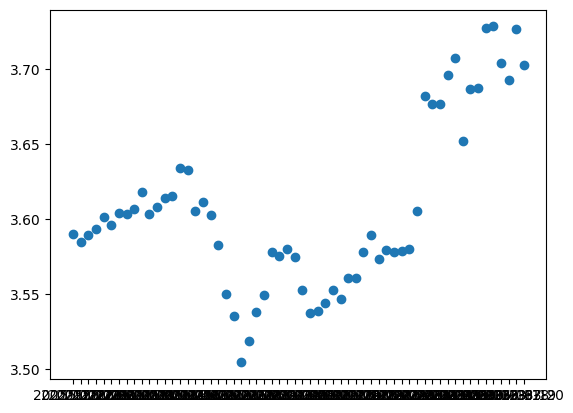

In [8]:
plt.scatter(df['Date'],df['CurenncyRate'])

In [9]:
df['Date'] = np.arange(len(df))
X = df[['Date']]
y = df['CurenncyRate']

/tmp/ipykernel_224/3003747420.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date'] = np.arange(len(df))


In [11]:
print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")

Shape X: (60, 1)
Shape y: (60,)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Expected currency rate: 3.6585 PLN


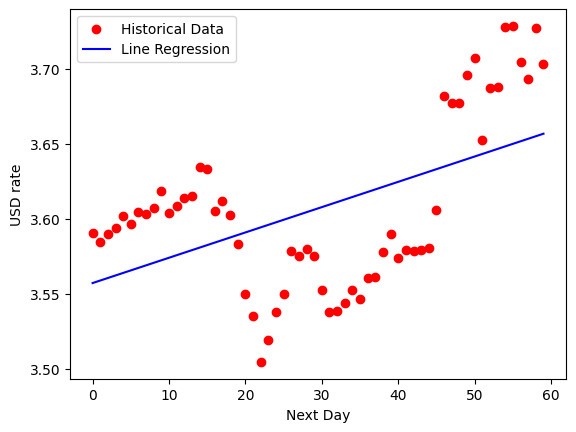

In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X,y)

next_day = np.array([[60]])
prediction = model.predict(next_day)

print(f'Expected currency rate: {prediction[0]:.4f} PLN')

plt.scatter(X,y, color='red',label='Historical Data')
plt.plot(X, model.predict(X), color='blue',label='Line Regression')
plt.xlabel('Next Day')
plt.ylabel('USD rate')
plt.legend()
plt.show()
